In [ ]:
!pip install ruptures scikit-learn tqdm matplotlib --quiet
print("All dependencies installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 63.2 MB/s eta 0:00:00
All dependencies installed.


In [ ]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Function
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, TensorDataset
from scipy.stats import spearmanr
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupKFold
import ruptures as rpt
import matplotlib.pyplot as plt
from tqdm import tqdm

def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [ ]:
BASE_DIR    = '/content/sample_data'
DATA_DIR    = BASE_DIR
RESULTS_DIR = os.path.join(BASE_DIR, 'results')
os.makedirs(DATA_DIR,    exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

In [ ]:
class Config:
    # ── Per-dataset tuned hyperparameters ────────────────────────────────
    # FD001/FD003 → 1 operating condition, FD002/FD004 → 6 conditions.
    # MAX_RUL: 125 for FD001/FD003 (literature), 130 for FD002/FD004.
    # WINDOW_SIZE: 30 cycles is sufficient for single-condition datasets;
    #              50 cycles better captures regime transitions in FD002/FD004.
    # N_REGIMES: KMeans clusters on operational settings (1→no clustering).
    DATASET_PARAMS = {
        'FD001': {'MAX_RUL': 125, 'WINDOW_SIZE': 30, 'N_REGIMES': 1},
        'FD002': {'MAX_RUL': 130, 'WINDOW_SIZE': 50, 'N_REGIMES': 6},
        'FD003': {'MAX_RUL': 125, 'WINDOW_SIZE': 30, 'N_REGIMES': 1},
        'FD004': {'MAX_RUL': 130, 'WINDOW_SIZE': 50, 'N_REGIMES': 6},
    }

    # ── Training ─────────────────────────────────────────────────────────
    BATCH_SIZE    = 256
    LEARNING_RATE = 1e-3
    WEIGHT_DECAY  = 1e-4
    EPOCHS        = 250
    PATIENCE      = 20

    # ── Loss weights ─────────────────────────────────────────────────────
    LAMBDA_NASA   = 1.0
    LAMBDA_MMD    = 0.5
    LAMBDA_DOMAIN = 0.5

    # ── Critical-zone weighting ───────────────────────────────────────────
    CRITICAL_THRESHOLD = 30
    CRITICAL_WEIGHT    = 2.5

    # ── Paths ─────────────────────────────────────────────────────────────
    DATA_PATH       = DATA_DIR
    MODEL_SAVE_PATH = os.path.join(RESULTS_DIR, 'best_model_{dataset}.pt')

    @staticmethod
    def get(dataset_id, key):
        return Config.DATASET_PARAMS[dataset_id][key]


In [ ]:
# ── Choose which sub-datasets to run ─────────────────────────────────
# Set DATASETS to any subset of ['FD001','FD002','FD003','FD004'].
DATASETS         = ['FD004']   # run all four
MODE             = 'train'   # 'train' | 'eval'
USE_CHANGEPOINT  = True     # Use PELT change-point RUL labelling
USE_GMM          = True      # Enable Autoencoder + GMM health-state gating
USE_DA           = False     # Enable Domain Adaptation (needs a target dataset)
USE_CQR          = False     # Enable Conformalized Quantile Regression

In [ ]:
class CMAPSSLoader:
    COLUMNS = (['engine_id', 'cycle', 'setting1', 'setting2', 'setting3']
               + [f's{i}' for i in range(1, 22)])

    def __init__(self, dataset_name='FD001'):
        self.dataset_name = dataset_name

    def load_data(self):
        paths = {
            'train': os.path.join(Config.DATA_PATH, f'train_{self.dataset_name}.txt'),
            'test':  os.path.join(Config.DATA_PATH, f'test_{self.dataset_name}.txt'),
            'rul':   os.path.join(Config.DATA_PATH, f'RUL_{self.dataset_name}.txt'),
        }
        for key, path in paths.items():
            if not os.path.exists(path):
                print(f'[ERROR] {key} file not found: {path}')
                return None, None, None
        train_df = pd.read_csv(paths['train'], sep=r'\s+', header=None, names=self.COLUMNS)
        test_df  = pd.read_csv(paths['test'],  sep=r'\s+', header=None, names=self.COLUMNS)
        rul_df   = pd.read_csv(paths['rul'],   sep=r'\s+', header=None, names=['RUL'])
        return train_df, test_df, rul_df

print('CMAPSSLoader defined.')

CMAPSSLoader defined.


In [ ]:

def group_kfold_split(df, n_splits=5, fold_idx=0):
    groups = df['engine_id'].values
    gkf    = GroupKFold(n_splits=n_splits)
    splits = list(gkf.split(df, groups=groups))
    train_idx, val_idx = splits[fold_idx]
    return df.iloc[train_idx].reset_index(drop=True), df.iloc[val_idx].reset_index(drop=True)


def normalize_zscore(train_df, test_df, columns, n_regimes=6):
    setting_cols = ['setting1', 'setting2', 'setting3']
    train_df = train_df.copy()
    test_df  = test_df.copy() if test_df is not None else None

    train_df[columns] = train_df[columns].bfill()
    if test_df is not None:
        test_df[columns] = test_df[columns].bfill()

    if n_regimes == 1:
        # Single operating condition: one global scaler
        scaler = StandardScaler()
        train_df[columns] = scaler.fit_transform(train_df[columns])
        if test_df is not None:
            test_df[columns] = scaler.transform(test_df[columns])
        return train_df, test_df, {'kmeans': None, 'scalers': {0: scaler}}

    kmeans = KMeans(n_clusters=n_regimes, random_state=42, n_init='auto')
    train_df['_regime'] = kmeans.fit_predict(train_df[setting_cols].values)
    scalers = {}
    for regime in range(n_regimes):
        mask = train_df['_regime'] == regime
        scaler = StandardScaler()
        if mask.sum() > 0:
            train_df.loc[mask, columns] = scaler.fit_transform(train_df.loc[mask, columns])
        scalers[regime] = scaler
    train_df.drop(columns=['_regime'], inplace=True)

    if test_df is not None:
        test_df['_regime'] = kmeans.predict(test_df[setting_cols].values)
        for regime, scaler in scalers.items():
            mask = test_df['_regime'] == regime
            if mask.sum() > 0:
                test_df.loc[mask, columns] = scaler.transform(test_df.loc[mask, columns])
        test_df.drop(columns=['_regime'], inplace=True)

    return train_df, test_df, {'kmeans': kmeans, 'scalers': scalers}


def select_sensors(df, threshold=0.1, rf_importance_threshold=0.01, rf_n_estimators=50):
    sensor_cols = [c for c in df.columns if c.startswith('s')]
    spearman_pass = {col for col in sensor_cols
                     if abs(spearmanr(df['cycle'], df[col])[0]) >= threshold}
    rf = RandomForestRegressor(n_estimators=rf_n_estimators, max_depth=6,
                               random_state=42, n_jobs=-1)
    rf.fit(df[sensor_cols].values, df['cycle'].values)
    rf_pass = {col for col, imp in zip(sensor_cols, rf.feature_importances_)
               if imp >= rf_importance_threshold}
    selected = sorted(spearman_pass | rf_pass, key=lambda c: int(c[1:]))
    print(f'  Spearman: {len(spearman_pass)} | RF rescued: {len(rf_pass - spearman_pass)} | Combined: {len(selected)} → {selected}')
    return selected


def sliding_window(df, sequence_length, columns, label_col='RUL'):
    data_list, label_list = [], []
    for _, group in df.groupby('engine_id'):
        data_matrix = group[columns].values
        labels      = group[label_col].values
        n           = len(group)
        if n < sequence_length:
            pad_data = np.pad(data_matrix, ((sequence_length - n, 0), (0, 0)),
                              mode='constant', constant_values=0)
            data_list.append(pad_data[np.newaxis, :, :])
            label_list.append(labels[-1])
            continue
        for i in range(n - sequence_length + 1):
            data_list.append(data_matrix[i:i + sequence_length, :])
            label_list.append(labels[i + sequence_length - 1])
    return np.array(data_list, dtype=np.float32), np.array(label_list, dtype=np.float32)


def extract_last_windows(test_df, features, window_size):
    """Last window per engine for evaluation (zero-masked if too short)."""
    X_last, y_last = [], []
    for _, group in test_df.groupby('engine_id'):
        data_matrix = group[features].values
        n = len(group)
        if n < window_size:
            X_last.append(np.pad(data_matrix, ((window_size - n, 0), (0, 0)),
                                 mode='constant', constant_values=0))
        else:
            X_last.append(data_matrix[-window_size:])
        y_last.append(group['RUL'].iloc[-1])
    return np.array(X_last, dtype=np.float32), np.array(y_last, dtype=np.float32)


def piecewise_linear_rul(df, max_rul=125):
    ruls, his = [], []
    for _, group in df.groupby('engine_id'):
        n   = len(group)
        idx = np.arange(n)
        ruls.extend(np.minimum(max_rul, np.arange(n - 1, -1, -1)))
        his.extend(1.0 - idx / max(n - 1, 1))
    return np.array(ruls), np.array(his)


def get_test_rul(test_df, true_rul_df, max_rul=125):
    ruls, his = [], []
    for (_, group), true_r in zip(test_df.groupby('engine_id'), true_rul_df['RUL']):
        n   = len(group)
        engine_rul = np.minimum(max_rul, np.arange(n - 1, -1, -1) + true_r)
        total_life = n + true_r
        hi = np.clip(1.0 - (np.arange(n) + true_r) / max(total_life - 1, 1), 0.0, 1.0)
        ruls.extend(engine_rul)
        his.extend(hi)
    return np.array(ruls), np.array(his)


def preprocess_pipeline(train_df, test_df, rul_df, dataset_id,
                         use_changepoint=False, n_folds=5, fold_idx=0):
    """Full pipeline using dataset-specific MAX_RUL, WINDOW_SIZE, N_REGIMES."""
    max_rul     = Config.get(dataset_id, 'MAX_RUL')
    window_size = Config.get(dataset_id, 'WINDOW_SIZE')
    n_regimes   = Config.get(dataset_id, 'N_REGIMES')

    print(f'  MAX_RUL={max_rul} | WINDOW_SIZE={window_size} | N_REGIMES={n_regimes}')

    # 1. Group K-Fold split
    train_fold_df, val_fold_df = group_kfold_split(train_df, n_splits=n_folds, fold_idx=fold_idx)

    # 3. Feature selection
    selected_sensors = select_sensors(train_fold_df)
    features = ['setting1', 'setting2', 'setting3'] + selected_sensors

    # 2. Regime-aware normalisation (fit on train fold, apply to val + test)
    train_fold_df, val_fold_df, norm_state = normalize_zscore(
        train_fold_df, val_fold_df, features, n_regimes=n_regimes
    )
    # Apply same clusters/scalers to test — reuse norm_state to avoid leakage
    kmeans, scalers = norm_state['kmeans'], norm_state['scalers']
    test_df = test_df.copy()
    test_df[features] = test_df[features].bfill()
    if kmeans is not None:
        test_df['_regime'] = kmeans.predict(test_df[['setting1','setting2','setting3']].values)
        for regime, scaler in scalers.items():
            mask = test_df['_regime'] == regime
            if mask.sum() > 0:
                test_df.loc[mask, features] = scaler.transform(test_df.loc[mask, features])
        test_df.drop(columns=['_regime'], inplace=True)
    else:
        test_df[features] = scalers[0].transform(test_df[features])

    # 5. RUL labels
    if use_changepoint:
        rul_tr = changepoint_rul(train_fold_df, max_rul=max_rul)
        _, hi_tr = piecewise_linear_rul(train_fold_df, max_rul=max_rul)
        rul_vl = changepoint_rul(val_fold_df,   max_rul=max_rul)
        _, hi_vl = piecewise_linear_rul(val_fold_df, max_rul=max_rul)
    else:
        rul_tr, hi_tr = piecewise_linear_rul(train_fold_df, max_rul=max_rul)
        rul_vl, hi_vl = piecewise_linear_rul(val_fold_df,   max_rul=max_rul)

    train_fold_df['RUL'], train_fold_df['HI'] = rul_tr, hi_tr
    val_fold_df['RUL'],   val_fold_df['HI']   = rul_vl, hi_vl

    rul_te, hi_te = get_test_rul(test_df, rul_df, max_rul=max_rul)
    test_df['RUL'], test_df['HI'] = rul_te, hi_te

    # 4. Sliding windows (zero-masked)
    X_train, y_train = sliding_window(train_fold_df, window_size, features, 'RUL')
    _, hi_train      = sliding_window(train_fold_df, window_size, features, 'HI')
    X_val,   y_val   = sliding_window(val_fold_df,   window_size, features, 'RUL')
    _, hi_val        = sliding_window(val_fold_df,   window_size, features, 'HI')

    X_test_last, y_test_last = extract_last_windows(test_df, features, window_size)
    hi_test_last = test_df.groupby('engine_id')['HI'].last().values.astype(np.float32)

    print(f'  Train: {X_train.shape} | Val: {X_val.shape} | Test(last): {X_test_last.shape}')
    return (
        (X_train, y_train, hi_train),
        (X_val,   y_val,   hi_val),
        (X_test_last, y_test_last, hi_test_last),
        features, window_size
    )

print('✅ Preprocessing functions defined.')

✅ Preprocessing functions defined.


In [ ]:
def detect_changepoint(engine_series, pen=10):
    algo   = rpt.Pelt(model='l2').fit(engine_series)
    result = algo.predict(pen=pen)
    return result[0] if len(result) > 1 else -1


def changepoint_rul(df, max_rul=125, pen=10):
    ruls        = []
    sensor_cols = [c for c in df.columns if c.startswith('s')]
    for _, group in df.groupby('engine_id'):
        agg = np.mean(group[sensor_cols].values, axis=1).reshape(-1, 1)
        cp  = detect_changepoint(agg, pen=pen)
        n   = len(group)
        if 0 < cp < n:
            flat = n - cp
            ruls.extend([flat] * cp + list(range(flat - 1, -1, -1)))
        else:
            ruls.extend(np.minimum(max_rul, np.arange(n - 1, -1, -1)).tolist())
    return np.array(ruls)

print('Change-point functions defined.')

Change-point functions defined.


In [ ]:
class SensorAttention(nn.Module):
    def __init__(self, in_features):
        super().__init__()
        self.fc = nn.Linear(in_features, in_features)

    def forward(self, x):
        return x * F.softmax(self.fc(x), dim=-1)


class TemporalAttention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2), nn.Tanh(),
            nn.Linear(hidden_size // 2, 1, bias=False),
        )

    def forward(self, x):
        weights = F.softmax(self.attention(x), dim=1)
        return torch.sum(x * weights, dim=1)


class CNNFeatureExtractor(nn.Module):
    def __init__(self, in_features, window_size):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(in_features, 64, kernel_size=5, padding=2),
            nn.LayerNorm([64, window_size]), nn.ReLU(),
            nn.Conv1d(64, 64, kernel_size=5, padding=2),
            nn.LayerNorm([64, window_size]), nn.ReLU(),
        )

    def forward(self, x):
        return self.conv(x.transpose(1, 2)).transpose(1, 2)


class RULPredictor(nn.Module):
    """CNN → Stacked BiLSTM (2 layers) → Temporal Attention → RUL head.

    Flow: Input → SensorAttention → CNNFeatureExtractor
               → BiLSTM (2 layers, hidden=128×2=256, dropout=0.3 between layers)
               → LayerNorm → TemporalAttention → [HealthState gate]
               → fc head (point estimate) + optional q_head (CQR bounds)

    BiLSTM notes
    ------------
    - bidirectional=True, hidden_size=128 → 256-d output per time step.
    - num_layers=2 activates inter-layer dropout (PyTorch ignores dropout
      when num_layers=1, so 2 layers is the minimum for real regularisation).
    - LayerNorm on the BiLSTM output stabilises training, especially on
      multi-condition datasets (FD002/FD004).
    """
    def __init__(self, in_features, window_size, use_gating=True, use_cqr=False):
        super().__init__()
        self.use_gating = use_gating
        self.use_cqr    = use_cqr

        self.sensor_att   = SensorAttention(in_features)
        self.cnn          = CNNFeatureExtractor(in_features, window_size)
        self.bilstm       = nn.LSTM(
            input_size=64, hidden_size=128,
            num_layers=2, batch_first=True,
            bidirectional=True, dropout=0.3,
        )
        self.lstm_norm    = nn.LayerNorm(256)
        self.temporal_att = TemporalAttention(256)

        if use_gating:
            self.health_embed = nn.Embedding(3, 256)

        self.fc = nn.Sequential(
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.2), nn.Linear(128, 1)
        )
        if use_cqr:
            self.q_head = nn.Sequential(
                nn.Linear(256, 128), nn.ReLU(), nn.Linear(128, 2)
            )

    def _context(self, x, health_states=None):
        x           = self.sensor_att(x)
        x           = self.cnn(x)
        lstm_out, _ = self.bilstm(x)
        lstm_out    = self.lstm_norm(lstm_out)
        ctx         = self.temporal_att(lstm_out)
        if self.use_gating and health_states is not None:
            ctx = ctx * torch.sigmoid(self.health_embed(health_states))
        return ctx

    def forward(self, x, health_states=None):
        ctx = self._context(x, health_states)
        rul = self.fc(ctx).squeeze(-1)
        if self.use_cqr:
            return rul, self.q_head(ctx)
        return rul

    def get_context(self, x, health_states=None):
        """Return 256-d context vector (used by MMD / domain adaptation)."""
        return self._context(x, health_states)

print('Model defined — Stacked BiLSTM (2 layers, dropout=0.3, LayerNorm) active.')


Model defined — Stacked BiLSTM (2 layers, dropout=0.3, LayerNorm) active.


In [ ]:
class ConvAutoencoder(nn.Module):
    def __init__(self, in_features, window_size):
        super().__init__()
        self.window_size = window_size
        self.encoder_conv = nn.Sequential(
            nn.Conv1d(in_features, 32, 3, padding=1), nn.ReLU(),
            nn.Conv1d(32,          64, 3, padding=1), nn.ReLU(),
            nn.Conv1d(64,          64, 3, padding=1), nn.ReLU(),
        )
        self.encoder_fc  = nn.Linear(64 * window_size, 16)
        self.decoder_fc  = nn.Linear(16, 64 * window_size)
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose1d(64, 64, 3, padding=1), nn.ReLU(),
            nn.ConvTranspose1d(64, 32, 3, padding=1), nn.ReLU(),
            nn.ConvTranspose1d(32, in_features, 3, padding=1),
        )

    def encode(self, x):
        h = self.encoder_conv(x.transpose(1, 2))
        return self.encoder_fc(h.view(h.size(0), -1))

    def forward(self, x):
        z = self.encode(x)
        h = self.decoder_fc(z).view(z.size(0), 64, self.window_size)
        return self.decoder_conv(h).transpose(1, 2)

    @torch.no_grad()
    def get_reconstruction_error(self, x):
        self.eval()
        return torch.mean((self.forward(x) - x) ** 2, dim=(1, 2)).cpu().numpy()

    @torch.no_grad()
    def get_latent(self, x):
        self.eval()
        return self.encode(x).cpu().numpy()


def filter_healthy_data(df, columns, window_size):
    healthy_data = []
    for _, group in df.groupby('engine_id'):
        n           = len(group)
        healthy_len = max(window_size + 1, int(0.2 * n))
        data_matrix = group[columns].iloc[:healthy_len].values
        for i in range(healthy_len - window_size + 1):
            healthy_data.append(data_matrix[i:i + window_size, :])
    return np.array(healthy_data)


class HealthStateGMM:
    def __init__(self, n_components=3):
        self.gmm = GaussianMixture(n_components=n_components,
                                    covariance_type='diag', random_state=42)
        self.cluster_mapping = {}

    def fit(self, latent_vectors, recon_errors):
        self.gmm.fit(latent_vectors)
        raw_labels = self.gmm.predict(latent_vectors)
        cluster_errors = [np.mean(recon_errors[raw_labels == i]) if (raw_labels == i).sum() > 0
                          else float('inf') for i in range(self.gmm.n_components)]
        self.cluster_mapping = {old: new for new, old in enumerate(np.argsort(cluster_errors))}

    def predict_health_state(self, latent_vectors):
        raw = self.gmm.predict(latent_vectors)
        out = np.zeros_like(raw)
        for old, new in self.cluster_mapping.items():
            out[raw == old] = new
        return out

print('ConvAutoencoder + HealthStateGMM defined.')

ConvAutoencoder + HealthStateGMM defined.


In [ ]:
class GradientReversalLayer(Function):
    @staticmethod
    def forward(ctx, x, lambda_grl):
        ctx.lambda_grl = lambda_grl
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return grad_output.neg() * ctx.lambda_grl, None


class DomainDiscriminator(nn.Module):
    def __init__(self, in_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 256), nn.ReLU(),
            nn.Linear(256, 128),          nn.ReLU(),
            nn.Linear(128, 1),
        )

    def forward(self, x, lambda_grl=1.0):
        return self.net(GradientReversalLayer.apply(x, lambda_grl))


def gaussian_kernel(source, target, kernel_mul=2.0, kernel_num=5, fix_sigma=None):
    n  = source.size(0) + target.size(0)
    t  = torch.cat([source, target], dim=0)
    t0 = t.unsqueeze(0).expand(n, n, t.size(1))
    t1 = t.unsqueeze(1).expand(n, n, t.size(1))
    L2 = ((t0 - t1) ** 2).sum(2)
    bw = (fix_sigma if fix_sigma else torch.sum(L2.data) / (n ** 2 - n))
    bw /= kernel_mul ** (kernel_num // 2)
    return sum(torch.exp(-L2 / (bw * kernel_mul ** i)) for i in range(kernel_num))


def mmd_rbf_loss(source, target, kernel_mul=2.0, kernel_num=5, fix_sigma=None):
    bs = source.size(0)
    k  = gaussian_kernel(source, target, kernel_mul, kernel_num, fix_sigma)
    return torch.mean(k[:bs, :bs] + k[bs:, bs:] - k[:bs, bs:] - k[bs:, :bs])

print('Domain adaptation components defined.')

Domain adaptation components defined.


In [ ]:
def nasa_score_loss(pred, true):
    d = pred - true
    return torch.mean(torch.where(d < 0, torch.exp(-d / 13.0) - 1, torch.exp(d / 10.0) - 1))


def critical_zone_weight(true_rul,
                         threshold=Config.CRITICAL_THRESHOLD,
                         multiplier=Config.CRITICAL_WEIGHT):
    w = torch.ones_like(true_rul)
    w[true_rul <= threshold] = multiplier
    return w


class RULLoss(nn.Module):
    def __init__(self, lambda_nasa=Config.LAMBDA_NASA,
                 lambda_mmd=Config.LAMBDA_MMD, lambda_domain=Config.LAMBDA_DOMAIN):
        super().__init__()
        self.lambda_nasa   = lambda_nasa
        self.lambda_mmd    = lambda_mmd
        self.lambda_domain = lambda_domain

    def forward(self, pred, true, mmd_loss=None, domain_loss=None):
        pred, true = pred.view(-1), true.view(-1)
        # Accept both float scalars and tensors from optional DA step
        dev = pred.device
        mmd_loss    = (mmd_loss    if mmd_loss    is not None else torch.zeros(1, device=dev)).squeeze()
        domain_loss = (domain_loss if domain_loss is not None else torch.zeros(1, device=dev)).squeeze()

        weights   = critical_zone_weight(true).view(-1)
        rmse_loss = torch.sqrt(torch.mean(weights * (pred - true) ** 2))
        nasa_loss = nasa_score_loss(pred, true)
        total = (rmse_loss
                 + self.lambda_nasa   * nasa_loss
                 + self.lambda_mmd    * mmd_loss
                 + self.lambda_domain * domain_loss)
        return total, rmse_loss, nasa_loss


def enable_dropout(model):
    """Set all Dropout layers to train mode for MC-Dropout inference."""
    for m in model.modules():
        if m.__class__.__name__.startswith('Dropout'):
            m.train()


def mc_dropout_predict(model, x, health_states=None, T=50):
    """Monte Carlo Dropout: T stochastic forward passes → (mean, std)."""
    model.eval()
    enable_dropout(model)
    predictions = []
    with torch.no_grad():
        for _ in range(T):
            out = model(x, health_states) if health_states is not None else model(x)
            predictions.append((out[0] if isinstance(out, tuple) else out).unsqueeze(0))
    predictions = torch.cat(predictions, dim=0)   # (T, batch)
    return predictions.mean(0).cpu().numpy(), predictions.std(0).cpu().numpy()


class ConformalQR:
    def __init__(self, alpha=0.2):
        self.alpha = alpha
        self.q_hat = None

    def calibrate(self, model, calib_loader, device='cpu'):
        model.eval()
        scores = []
        with torch.no_grad():
            for batch in calib_loader:
                x, y = batch[0].to(device), batch[1].to(device)
                h    = batch[2].to(device) if len(batch) >= 3 else None
                out  = model(x, h) if h is not None else model(x)
                if not isinstance(out, tuple):
                    raise RuntimeError('Model must have use_cqr=True for CQR calibration.')
                q = out[1]
                scores.extend(torch.maximum(q[:, 0] - y, y - q[:, 1]).cpu().numpy())
        scores  = np.array(scores)
        q_level = np.clip(np.ceil((len(scores) + 1) * (1 - self.alpha)) / len(scores), 0.0, 1.0)
        self.q_hat = np.quantile(scores, q_level)
        print(f'Calibration q_hat = {self.q_hat:.4f}')

    def predict_interval(self, model, x, health_states=None, device='cpu'):
        if self.q_hat is None:
            raise ValueError('Call calibrate() first.')
        model.eval()
        with torch.no_grad():
            x   = x.to(device)
            out = model(x, health_states.to(device)) if health_states is not None else model(x)
            if not isinstance(out, tuple):
                raise RuntimeError('Model must have use_cqr=True for predict_interval.')
            q = out[1].cpu().numpy()
        return q[:, 0] - self.q_hat, q[:, 1] + self.q_hat

print('Loss + uncertainty modules defined.')


Loss + uncertainty modules defined.


In [ ]:
def compute_nasa_score(pred, true):
    d = pred - true
    return np.sum(np.where(d < 0, np.exp(-d / 13.0) - 1, np.exp(d / 10.0) - 1))


def compute_rmse(pred, true):
    return np.sqrt(np.mean((pred - true) ** 2))


class Evaluator:
    def __init__(self, model, device='cpu'):
        self.model  = model
        self.device = device

    def evaluate(self, test_loader):
        self.model.eval()
        all_preds, all_trues = [], []
        with torch.no_grad():
            for batch in test_loader:
                x, y = batch[0].to(self.device), batch[1].to(self.device)
                h    = batch[2].to(self.device) if len(batch) >= 3 else None
                out  = self.model(x, h) if h is not None else self.model(x)
                preds = out[0] if isinstance(out, tuple) else out
                all_preds.extend(preds.cpu().numpy())
                all_trues.extend(y.cpu().numpy())
        all_preds, all_trues = np.array(all_preds), np.array(all_trues)
        return {'rmse': compute_rmse(all_preds, all_trues),
                'nasa': compute_nasa_score(all_preds, all_trues),
                'preds': all_preds, 'trues': all_trues}

    def plot_rul(self, preds, trues, title='True vs Predicted RUL', save_path=None):
        idx = np.argsort(trues)[::-1]
        plt.figure(figsize=(12, 5))
        plt.plot(trues[idx], label='True RUL',      color='steelblue', linewidth=2)
        plt.plot(preds[idx], label='Predicted RUL', color='tomato',    alpha=0.8)
        plt.xlabel('Sample (sorted by True RUL)'); plt.ylabel('RUL (cycles)')
        plt.title(title); plt.legend(); plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150); plt.close()
        else:
            plt.show()

print('Evaluator defined.')

Evaluator defined.


In [ ]:
class Trainer:
    def __init__(self, model, train_loader, val_loader=None,
                 device='cpu', use_da=False, target_loader=None):
        self.model        = model.to(device)
        self.train_loader = train_loader
        self.val_loader   = val_loader
        self.device       = device
        self.use_da       = use_da
        self.criterion    = RULLoss().to(device)
        self.optimizer    = AdamW(model.parameters(),
                                  lr=Config.LEARNING_RATE,
                                  weight_decay=Config.WEIGHT_DECAY)
        self.scheduler    = ReduceLROnPlateau(self.optimizer, mode='min',
                                              factor=0.5, patience=10)
        if use_da:
            if target_loader is None:
                raise ValueError('target_loader required when use_da=True.')
            self.target_loader = target_loader
            self.target_iter   = iter(target_loader)
            self.domain_disc   = DomainDiscriminator(256).to(device)
            self.da_optimizer  = AdamW(self.domain_disc.parameters(), lr=Config.LEARNING_RATE)
            self.bce_loss      = nn.BCEWithLogitsLoss()
        else:
            self.target_loader = None

    def _get_target_batch(self):
        try:
            return next(self.target_iter)
        except StopIteration:
            self.target_iter = iter(self.target_loader)
            return next(self.target_iter)

    def _da_step(self, src_context, lambda_grl):
        tgt_batch   = self._get_target_batch()
        x_tgt       = tgt_batch[0].to(self.device)
        h_tgt       = tgt_batch[2].to(self.device) if len(tgt_batch) >= 3 else None
        with torch.no_grad():
            tgt_context = self.model.get_context(x_tgt, h_tgt)
        mmd = mmd_rbf_loss(src_context, tgt_context)
        src_logits = self.domain_disc(src_context, lambda_grl)
        tgt_logits = self.domain_disc(tgt_context.detach(), lambda_grl)
        src_lab    = torch.ones (src_logits.size(0), 1, device=self.device)
        tgt_lab    = torch.zeros(tgt_logits.size(0), 1, device=self.device)
        adv_loss   = (self.bce_loss(src_logits, src_lab) + self.bce_loss(tgt_logits, tgt_lab)) / 2
        self.da_optimizer.zero_grad()
        adv_loss.backward(retain_graph=True)
        self.da_optimizer.step()
        return mmd, adv_loss.detach()

    def train(self, epochs=Config.EPOCHS, patience=Config.PATIENCE):
        best_rmse, patience_counter = float('inf'), 0
        os.makedirs(os.path.dirname(Config.MODEL_SAVE_PATH), exist_ok=True)
        for epoch in range(epochs):
            self.model.train()
            train_loss = 0.0
            lambda_grl = 2.0 / (1.0 + np.exp(-10 * epoch / epochs)) - 1
            pbar = tqdm(self.train_loader, desc=f'Epoch {epoch+1}/{epochs}')
            for batch in pbar:
                self.optimizer.zero_grad()
                x, y = batch[0].to(self.device), batch[1].to(self.device)
                h    = batch[2].to(self.device) if len(batch) >= 3 else None
                out  = self.model(x, h) if h is not None else self.model(x)
                preds = out[0] if isinstance(out, tuple) else out
                mmd_loss = domain_loss = None
                if self.use_da:
                    src_ctx = self.model.get_context(x, h)
                    mmd_loss, domain_loss = self._da_step(src_ctx, lambda_grl)
                loss, rmse, _ = self.criterion(preds, y, mmd_loss, domain_loss)
                loss.backward()
                nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
                self.optimizer.step()
                train_loss += loss.item()
                pbar.set_postfix({'loss': f'{loss.item():.4f}', 'rmse': f'{rmse.item():.4f}'})
            train_loss /= len(self.train_loader)
            val_rmse    = self.validate()
            self.scheduler.step(val_rmse)
            print(f'Epoch {epoch+1:3d} | train_loss={train_loss:.4f} | val_RMSE={val_rmse:.4f}')
            if val_rmse < best_rmse:
                best_rmse, patience_counter = val_rmse, 0
                torch.save(self.model.state_dict(), Config.MODEL_SAVE_PATH)
                print(f'  ✓ Best model saved (RMSE={best_rmse:.4f})')
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print('Early stopping triggered.'); break
        return best_rmse

    def validate(self):
        if self.val_loader is None:
            return 0.0
        self.model.eval()
        all_preds, all_trues = [], []
        with torch.no_grad():
            for batch in self.val_loader:
                x, y = batch[0].to(self.device), batch[1].to(self.device)
                h    = batch[2].to(self.device) if len(batch) >= 3 else None
                out  = self.model(x, h) if h is not None else self.model(x)
                preds = out[0] if isinstance(out, tuple) else out
                all_preds.extend(preds.cpu().numpy())
                all_trues.extend(y.cpu().numpy())
        return compute_rmse(np.array(all_preds), np.array(all_trues))

print('Trainer defined.')

Trainer defined.


In [ ]:

all_results = {}   # dataset_id → {rmse, nasa}
FOLD_IDX    = 0    # which Group-KFold split to use

for dataset_id in DATASETS:
    print(f'\n{'='*60}')
    print(f'  Dataset: {dataset_id}')
    print(f'{'='*60}')

    # ── Load data ────────────────────────────────────────────────────
    loader = CMAPSSLoader(dataset_id)
    train_df, test_df, rul_df = loader.load_data()
    if train_df is None:
        print(f'  [SKIP] {dataset_id} files not found.')
        continue

    # ── Preprocess ───────────────────────────────────────────────────
    (X_train, y_train, hi_train), \
    (X_val,   y_val,   hi_val),   \
    (X_test_last, y_test_last, hi_test_last), \
    features, window_size = preprocess_pipeline(
        train_df, test_df, rul_df, dataset_id,
        use_changepoint=USE_CHANGEPOINT,
        n_folds=5, fold_idx=FOLD_IDX
    )
    in_features = len(features)

    # ── GMM Health States ─────────────────────────────────────────────
    if USE_GMM:
        print('  Training AE for health states …')
        healthy_windows = filter_healthy_data(train_df, features, window_size)
        healthy_t       = torch.FloatTensor(healthy_windows).to(device)
        ae              = ConvAutoencoder(in_features, window_size).to(device)
        ae_opt          = torch.optim.Adam(ae.parameters(), lr=1e-3)
        ae.train()
        for ep in range(50):
            ae_opt.zero_grad()
            loss = F.mse_loss(ae(healthy_t), healthy_t)
            loss.backward(); ae_opt.step()
            if (ep + 1) % 10 == 0:
                print(f'    AE [{ep+1}/50] loss={loss.item():.5f}')

        X_train_t = torch.FloatTensor(X_train).to(device)
        Z_train   = ae.get_latent(X_train_t)
        gmm       = HealthStateGMM()
        gmm.fit(Z_train, ae.get_reconstruction_error(X_train_t))
        H_train   = gmm.predict_health_state(Z_train)

        X_val_t  = torch.FloatTensor(X_val).to(device)
        H_val    = gmm.predict_health_state(ae.get_latent(X_val_t))
        X_test_t = torch.FloatTensor(X_test_last).to(device)
        H_test   = gmm.predict_health_state(ae.get_latent(X_test_t))

        train_ds = TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train), torch.LongTensor(H_train))
        val_ds   = TensorDataset(torch.FloatTensor(X_val),   torch.FloatTensor(y_val),   torch.LongTensor(H_val))
        test_ds  = TensorDataset(torch.FloatTensor(X_test_last), torch.FloatTensor(y_test_last), torch.LongTensor(H_test))
    else:
        train_ds = TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train))
        val_ds   = TensorDataset(torch.FloatTensor(X_val),   torch.FloatTensor(y_val))
        test_ds  = TensorDataset(torch.FloatTensor(X_test_last), torch.FloatTensor(y_test_last))
        ae = gmm = H_test = None

    train_loader = DataLoader(train_ds, batch_size=Config.BATCH_SIZE, shuffle=True,  num_workers=0)
    val_loader   = DataLoader(val_ds,   batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=0)
    test_loader  = DataLoader(test_ds,  batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=0)

    # ── DA target loader (optional) ───────────────────────────────────
    target_loader = None
    if USE_DA:
        # Use next dataset in sequence as target domain, or skip if last
        next_idx = DATASETS.index(dataset_id) + 1
        if next_idx < len(DATASETS):
            tgt_id  = DATASETS[next_idx]
            tgt_loader_obj = CMAPSSLoader(tgt_id)
            tgt_train, _, _ = tgt_loader_obj.load_data()
            if tgt_train is not None:
                tgt_sensors  = select_sensors(tgt_train)
                tgt_features = ['setting1', 'setting2', 'setting3'] + tgt_sensors
                tgt_n_reg    = Config.get(tgt_id, 'N_REGIMES')
                tgt_win      = Config.get(tgt_id, 'WINDOW_SIZE')
                tgt_train, _, _ = normalize_zscore(tgt_train, None, tgt_features, n_regimes=tgt_n_reg)
                rul_tgt, hi_tgt = piecewise_linear_rul(tgt_train, max_rul=Config.get(tgt_id, 'MAX_RUL'))
                tgt_train['RUL'], tgt_train['HI'] = rul_tgt, hi_tgt
                X_tgt, y_tgt = sliding_window(tgt_train, tgt_win, tgt_features, 'RUL')
                tgt_ds = TensorDataset(torch.FloatTensor(X_tgt), torch.FloatTensor(y_tgt))
                target_loader = DataLoader(tgt_ds, batch_size=Config.BATCH_SIZE, shuffle=True, num_workers=0)
                print(f'  DA target: {tgt_id} ({X_tgt.shape[0]} windows)')
        else:
            print('  DA: no next dataset available, skipping.')

    # ── Build & Train Model ───────────────────────────────────────────
    Config.MODEL_SAVE_PATH = os.path.join(RESULTS_DIR, f'best_model_{dataset_id}.pt')
    model = RULPredictor(in_features, window_size=window_size,
                          use_gating=USE_GMM, use_cqr=USE_CQR)
    print(f'  Params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

    if MODE == 'train':
        trainer   = Trainer(model, train_loader, val_loader=val_loader,
                            device=device, use_da=USE_DA, target_loader=target_loader)
        best_rmse = trainer.train()
        print(f'  Best val RMSE: {best_rmse:.4f}')

    # ── Evaluate ─────────────────────────────────────────────────────
    model.load_state_dict(torch.load(Config.MODEL_SAVE_PATH, map_location=device, weights_only=True))
    evaluator = Evaluator(model, device)
    metrics   = evaluator.evaluate(test_loader)
    print(f'  Test RMSE  : {metrics["rmse"]:.4f}')
    print(f'  NASA Score : {metrics["nasa"]:.4f}')
    plot_path = os.path.join(RESULTS_DIR, f'rul_plot_{dataset_id}.png')
    evaluator.plot_rul(metrics['preds'], metrics['trues'],
                       title=f'True vs Predicted RUL — {dataset_id}', save_path=plot_path)
    print(f'  Plot saved : {plot_path}')
    all_results[dataset_id] = {'rmse': metrics['rmse'], 'nasa': metrics['nasa']}

# ── Summary table ────────────────────────────────────────────────────
print('\n' + '='*50)
print(f'{"Dataset":<10} {"RMSE":>10} {"NASA Score":>12}')
print('-'*50)
for ds, m in all_results.items():
    print(f'{ds:<10} {m["rmse"]:>10.4f} {m["nasa"]:>12.4f}')
print('='*50)

MC-Dropout uncertainty on FD004 (T=50) …


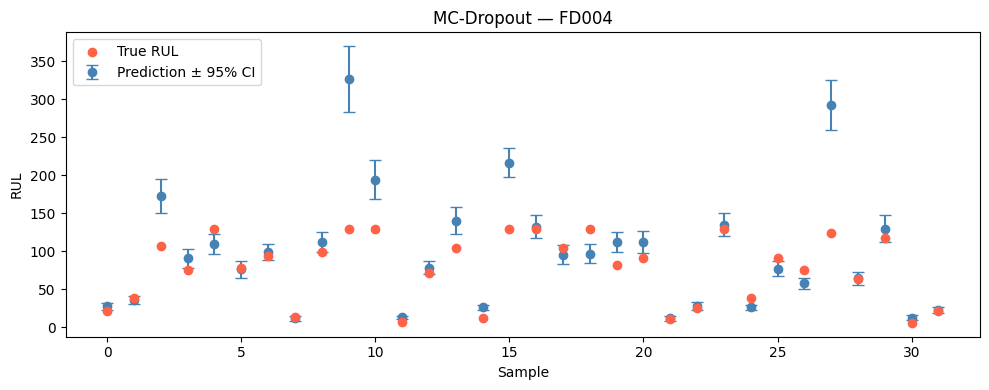

In [ ]:
# MC-Dropout on the last trained model / dataset
if all_results:
    last_ds = list(all_results.keys())[-1]
    print(f'MC-Dropout uncertainty on {last_ds} (T=50) …')
    x_sample = torch.FloatTensor(X_test_last[:32]).to(device)
    h_sample  = torch.LongTensor(H_test[:32]).to(device) if USE_GMM and H_test is not None else None
    mean_pred, std_pred = mc_dropout_predict(model, x_sample, health_states=h_sample, T=50)
    plt.figure(figsize=(10, 4))
    plt.errorbar(range(len(mean_pred)), mean_pred, yerr=1.96 * std_pred,
                 fmt='o', capsize=4, color='steelblue', label='Prediction ± 95% CI')
    plt.scatter(range(len(mean_pred)), y_test_last[:32], color='tomato', zorder=5, label='True RUL')
    plt.xlabel('Sample'); plt.ylabel('RUL'); plt.title(f'MC-Dropout — {last_ds}')
    plt.legend(); plt.tight_layout(); plt.show()

In [ ]:
if USE_CQR and all_results:
    print('Calibrating CQR …')
    cqr = ConformalQR(alpha=0.1)
    cqr.calibrate(model, test_loader, device=device)
    lb, ub = cqr.predict_interval(model, x_sample, health_states=h_sample, device=device)
    true_s  = y_test_last[:32]
    covered = np.mean((true_s >= lb) & (true_s <= ub))
    print(f'Empirical coverage: {covered:.2%}')
    idx = np.argsort(true_s)
    plt.figure(figsize=(10, 4))
    plt.fill_between(range(32), lb[idx], ub[idx], alpha=0.3, color='steelblue', label='90% PI')
    plt.scatter(range(32), true_s[idx], color='tomato', zorder=5, label='True RUL')
    plt.xlabel('Sample'); plt.ylabel('RUL'); plt.title('CQR Intervals')
    plt.legend(); plt.tight_layout(); plt.show()
else:
    print('CQR disabled (set USE_CQR=True to enable).')

CQR disabled (set USE_CQR=True to enable).



=== Evaluating FD004 ===
  MAX_RUL=130 | WINDOW_SIZE=50 | N_REGIMES=6
  Spearman: 3 | RF rescued: 7 | Combined: 10 → ['s6', 's7', 's8', 's9', 's10', 's11', 's12', 's13', 's14', 's15']
  Train: (39218, 50, 13) | Val: (9830, 50, 13) | Test(last): (248, 50, 13)
  Loaded checkpoint: /content/sample_data/results/best_model_FD004.pt
  Test RMSE  : 39.4195
  NASA Score : 391466944.0000
  Plot saved : /content/sample_data/results/rul_plot_FD004.png


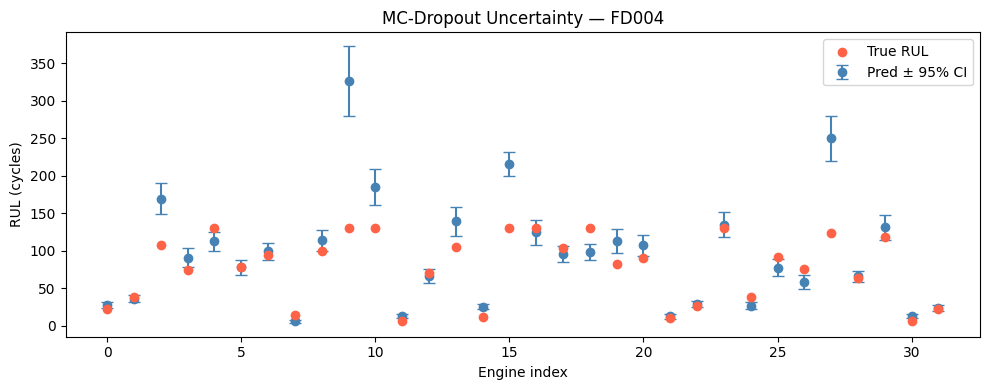


Dataset          RMSE   NASA Score
--------------------------------------------------
FD004         39.4195 391466944.0000


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# STANDALONE TEST / EVALUATION
# ───────────────────────────────────────────────────────────────────────────
# Run this cell independently after training is complete.
# Set MODE = 'eval' in the flags cell to skip training and only evaluate.
#
# Steps performed:
#   1. Load the saved best_model_<dataset>.pt checkpoint
#   2. Reconstruct the exact same test windows used during training
#   3. Predict RUL for the last window of each test engine
#   4. Compute RMSE and NASA asymmetric score
#   5. Plot True vs Predicted RUL (sorted by true RUL)
#   6. Run MC-Dropout for uncertainty bounds
# ═══════════════════════════════════════════════════════════════════════════

def evaluate_dataset(dataset_id, use_gmm=USE_GMM, use_cqr=USE_CQR, fold_idx=0):
    """
    Full test evaluation for one C-MAPSS sub-dataset.

    Parameters
    ----------
    dataset_id : str   e.g. 'FD001', 'FD002', 'FD003', 'FD004'
    use_gmm    : bool  must match the flag used during training
    use_cqr    : bool  must match the flag used during training
    fold_idx   : int   must match the fold used during training (default 0)

    Returns
    -------
    dict with keys: 'rmse', 'nasa', 'preds', 'trues'
    """
    print(f'\n=== Evaluating {dataset_id} ===')

    # ── 1. Load raw data ──────────────────────────────────────────────
    loader = CMAPSSLoader(dataset_id)
    train_df, test_df, rul_df = loader.load_data()
    if train_df is None:
        print(f'  [ERROR] Data files not found for {dataset_id}.')
        return None

    # ── 2. Preprocess (identical pipeline to training) ────────────────
    (X_train, y_train, hi_train),     (X_val,   y_val,   hi_val),       (X_test_last, y_test_last, hi_test_last),     features, window_size = preprocess_pipeline(
        train_df, test_df, rul_df, dataset_id,
        use_changepoint=USE_CHANGEPOINT,
        n_folds=5, fold_idx=fold_idx
    )
    in_features = len(features)

    # ── 3. GMM health states (if enabled) ────────────────────────────
    if use_gmm:
        healthy_windows = filter_healthy_data(train_df, features, window_size)
        healthy_t       = torch.FloatTensor(healthy_windows).to(device)
        ae              = ConvAutoencoder(in_features, window_size).to(device)
        ae_opt          = torch.optim.Adam(ae.parameters(), lr=1e-3)
        ae.train()
        for ep in range(50):
            ae_opt.zero_grad()
            loss = F.mse_loss(ae(healthy_t), healthy_t)
            loss.backward(); ae_opt.step()
        ae.eval()
        X_test_t = torch.FloatTensor(X_test_last).to(device)
        Z_train  = ae.get_latent(torch.FloatTensor(X_train).to(device))
        err_tr   = ae.get_reconstruction_error(torch.FloatTensor(X_train).to(device))
        gmm_     = HealthStateGMM()
        gmm_.fit(Z_train, err_tr)
        H_test   = gmm_.predict_health_state(ae.get_latent(X_test_t))
        test_ds  = TensorDataset(
            torch.FloatTensor(X_test_last),
            torch.FloatTensor(y_test_last),
            torch.LongTensor(H_test),
        )
    else:
        H_test  = None
        test_ds = TensorDataset(
            torch.FloatTensor(X_test_last),
            torch.FloatTensor(y_test_last),
        )

    test_loader = DataLoader(test_ds, batch_size=Config.BATCH_SIZE,
                              shuffle=False, num_workers=0)

    # ── 4. Load saved model ───────────────────────────────────────────
    model_path = os.path.join(RESULTS_DIR, f'best_model_{dataset_id}.pt')
    if not os.path.exists(model_path):
        print(f'  [ERROR] Checkpoint not found: {model_path}')
        print(  '          Train the model first (set MODE = "train").')
        return None

    model = RULPredictor(in_features, window_size=window_size,
                          use_gating=use_gmm, use_cqr=use_cqr)
    model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
    model.to(device)
    print(f'  Loaded checkpoint: {model_path}')

    # ── 5. Evaluate ───────────────────────────────────────────────────
    evaluator = Evaluator(model, device)
    metrics   = evaluator.evaluate(test_loader)
    print(f'  Test RMSE  : {metrics["rmse"]:.4f}')
    print(f'  NASA Score : {metrics["nasa"]:.4f}')

    # ── 6. RUL plot ───────────────────────────────────────────────────
    plot_path = os.path.join(RESULTS_DIR, f'rul_plot_{dataset_id}.png')
    evaluator.plot_rul(metrics['preds'], metrics['trues'],
                       title=f'True vs Predicted RUL — {dataset_id}',
                       save_path=plot_path)
    print(f'  Plot saved : {plot_path}')

    # ── 7. MC-Dropout uncertainty (first 32 test engines) ─────────────
    n_sample  = min(32, len(X_test_last))
    x_sample  = torch.FloatTensor(X_test_last[:n_sample]).to(device)
    h_sample  = (torch.LongTensor(H_test[:n_sample]).to(device)
                 if use_gmm and H_test is not None else None)
    mean_pred, std_pred = mc_dropout_predict(model, x_sample,
                                              health_states=h_sample, T=50)
    plt.figure(figsize=(10, 4))
    plt.errorbar(range(n_sample), mean_pred, yerr=1.96 * std_pred,
                 fmt='o', capsize=4, color='steelblue', label='Pred ± 95% CI')
    plt.scatter(range(n_sample), y_test_last[:n_sample],
                color='tomato', zorder=5, label='True RUL')
    plt.xlabel('Engine index'); plt.ylabel('RUL (cycles)')
    plt.title(f'MC-Dropout Uncertainty — {dataset_id}')
    plt.legend(); plt.tight_layout(); plt.show()

    return metrics


# ── Run evaluation on one or all datasets ────────────────────────────────
# To test a single dataset:
#   results = evaluate_dataset('FD001')
#
# To test all datasets and print a summary table:
test_results = {}
for ds in DATASETS:
    m = evaluate_dataset(ds)
    if m:
        test_results[ds] = m

if test_results:
    print('\n' + '='*50)
    print(f'{"Dataset":<10} {"RMSE":>10} {"NASA Score":>12}')
    print('-'*50)
    for ds, m in test_results.items():
        print(f'{ds:<10} {m["rmse"]:>10.4f} {m["nasa"]:>12.4f}')
    print('='*50)
